In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
df_waze_09 = pd.read_csv("waze_09_2023.csv", sep=",")
df_waze_10 = pd.read_csv("waze_10_2023.csv", sep=",")


df_waze = pd.concat([df_waze_09, df_waze_10], ignore_index=True)



In [2]:
display(df_waze.head(5))

,delay,entity_id,entity_ts,length,level,position,speed,street
0,-1,WAZE.jams.1644886546,2023-08-31T23:00:44.000Z,135,5,"{'type': 'GeometryCollection', 'geometries': [...",0.0,Av. 24 de Julho
1,-1,WAZE.jams.1612496668,2023-08-31T23:00:44.000Z,43,5,"{'type': 'GeometryCollection', 'geometries': [...",0.0,R. da Prata
2,-1,WAZE.jams.1241403646,2023-08-31T23:00:44.000Z,37,5,"{'type': 'GeometryCollection', 'geometries': [...",0.0,R. do Azevinho
3,-1,WAZE.jams.1241403644,2023-08-31T23:00:44.000Z,72,5,"{'type': 'GeometryCollection', 'geometries': [...",0.0,Estr. das Laranjeiras
4,-1,WAZE.jams.625944902,2023-08-31T23:00:44.000Z,14,5,"{'type': 'GeometryCollection', 'geometries': [...",0.0,NaN


In [3]:
df_waze.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3932307 entries, 0 to 3932306
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   delay      int64  
 1   entity_id  object 
 2   entity_ts  object 
 3   length     int64  
 4   level      int64  
 5   position   object 
 6   speed      float64
 7   street     object 
dtypes: float64(1), int64(3), object(4)
memory usage: 240.0+ MB


In [4]:
df_waze['entity_ts'] = pd.to_datetime(df_waze['entity_ts'])

data_inicio = pd.to_datetime('2023-09-01')
data_fim = pd.to_datetime('2023-10-31')


fora_intervalo = df_waze[
    (df_waze['entity_ts'].dt.date < data_inicio.date()) | 
    (df_waze['entity_ts'].dt.date > data_fim.date())
]

print(f"Total de linhas com data fora do intervalo de 1 de setembro a 31 de outubro de 2023: {len(fora_intervalo)}")


datas_fora = fora_intervalo['entity_ts'].dt.date.drop_duplicates().sort_values()
print("\nDatas encontradas fora do intervalo:")
print(datas_fora.tolist())

Total de linhas com data fora do intervalo de 1 de setembro a 31 de outubro de 2023: 1702

Datas encontradas fora do intervalo:
[datetime.date(2023, 8, 31)]


In [5]:
df_waze= df_waze[~df_waze['entity_ts'].dt.date.isin(datas_fora)]

fora_intervalo = df_waze[
    (df_waze['entity_ts'].dt.date < data_inicio.date()) | 
    (df_waze['entity_ts'].dt.date > data_fim.date())
]

print(f"Total de linhas com data fora do intervalo de 1 de setembro a 31 de outubro de 2023: {len(fora_intervalo)}")

Total de linhas com data fora do intervalo de 1 de setembro a 31 de outubro de 2023: 0


In [6]:
unique_counts = df_waze.nunique()

print(unique_counts)

delay          3156
entity_id    292235
entity_ts    139989
length         2883
level             5
position      34367
speed          5226
street         2945
dtype: int64


In [7]:
df_waze.isnull().sum()

delay             0
entity_id         0
entity_ts         0
length            0
level             0
position          0
speed             0
street       357426
dtype: int64

In [8]:
df_waze.notnull().sum()

delay        3930605
entity_id    3930605
entity_ts    3930605
length       3930605
level        3930605
position     3930605
speed        3930605
street       3573179
dtype: int64

In [9]:
df_waze = df_waze.drop(columns=['entity_id'])

## Exploração

entity_ts
0     115553
1     109109
2     107597
3     104917
4     106025
5     109343
6     130471
7     229954
8     234236
9     193294
10    192558
11    191193
12    166824
13    155993
14    176057
15    204435
16    259197
17    269978
18    220493
19    163471
20    128654
21    122492
22    123510
23    115251
Name: count, dtype: int64


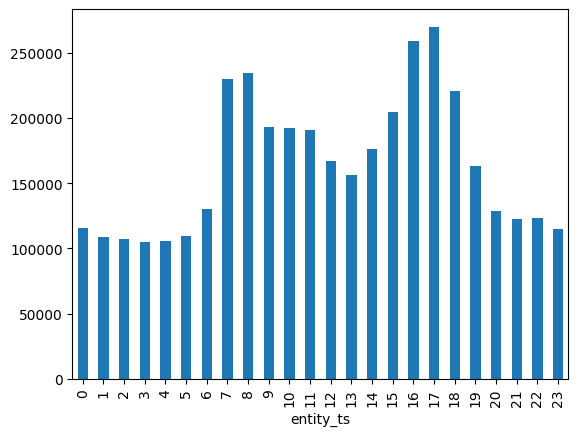

In [10]:
distribuicao = df_waze['entity_ts'].dt.hour.value_counts().sort_index()
distribuicao.plot(kind='bar')
print(distribuicao)


Número de registos por dia:
entity_ts
2023-09-01    49296
2023-09-02    49389
2023-09-03    44861
2023-09-04    53469
2023-09-05    56254
              ...  
2023-10-27    70606
2023-10-28    61787
2023-10-29    50913
2023-10-30    66982
2023-10-31    73356
Name: count, Length: 61, dtype: int64


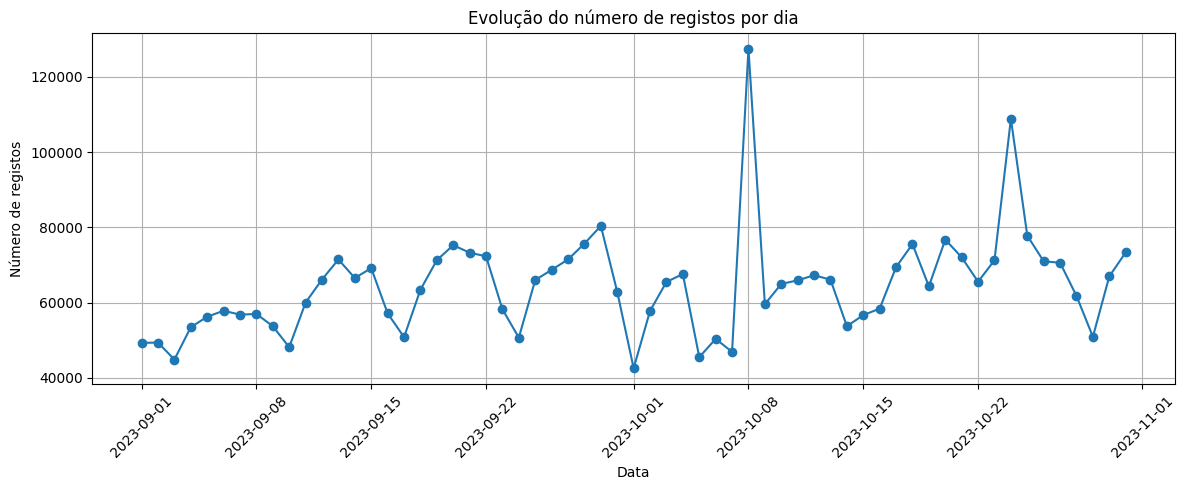

In [11]:
contagem_por_data = df_waze['entity_ts'].dt.date.value_counts().sort_index()

print("\nNúmero de registos por dia:")
print(contagem_por_data)

plt.figure(figsize=(12, 5))
contagem_por_data.plot(kind='line', marker='o')
plt.title("Evolução do número de registos por dia")
plt.xlabel("Data")
plt.ylabel("Número de registos")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(contagem_por_data)


entity_ts
2023-09-01     49296
2023-09-02     49389
2023-09-03     44861
2023-09-04     53469
2023-09-05     56254
2023-09-06     57839
2023-09-07     56808
2023-09-08     56994
2023-09-09     53726
2023-09-10     48149
2023-09-11     60034
2023-09-12     66151
2023-09-13     71479
2023-09-14     66540
2023-09-15     69177
2023-09-16     57155
2023-09-17     50825
2023-09-18     63431
2023-09-19     71290
2023-09-20     75270
2023-09-21     73286
2023-09-22     72321
2023-09-23     58223
2023-09-24     50692
2023-09-25     66015
2023-09-26     68712
2023-09-27     71485
2023-09-28     75703
2023-09-29     80404
2023-09-30     62860
2023-10-01     42568
2023-10-02     57802
2023-10-03     65508
2023-10-04     67597
2023-10-05     45498
2023-10-06     50358
2023-10-07     46902
2023-10-08    127495
2023-10-09     59590
2023-10-10     64971
2023-10-11     65929
2023-10-12     67287
2023-10-13     66106
2023-10-14     53738
2023-10-15     56678
2023-10-16     58407
2023-10-17     69447
202

In [13]:
df_dias = contagem_por_data.reset_index()
df_dias.columns = ['Data', 'Número de Registos']

# Ordena pelos dias com mais registos
top_dias = df_dias.sort_values(by='Número de Registos', ascending=False).head(10)

print("\nTop 10 dias com mais registos:")
for _, row in top_dias.iterrows():
    dia_semana = pd.to_datetime(row['Data']).day_name(locale='pt_PT')  
    print(f"{row['Data']} ({dia_semana}): {row['Número de Registos']}")


Top 10 dias com mais registos:
2023-10-08 (Domingo): 127495
2023-10-24 (Terça-feira): 108889
2023-09-29 (Sexta-feira): 80404
2023-10-25 (Quarta-feira): 77804
2023-10-20 (Sexta-feira): 76757
2023-09-28 (Quinta-feira): 75703
2023-10-18 (Quarta-feira): 75574
2023-09-20 (Quarta-feira): 75270
2023-10-31 (Terça-feira): 73356
2023-09-21 (Quinta-feira): 73286


In [14]:
dias_com_menos = df_dias.sort_values(by='Número de Registos', ascending=True).head(10)

print("\nTop 10 dias com menos registos:")
for _, row in dias_com_menos.iterrows():
    dia_semana = pd.to_datetime(row['Data']).day_name(locale='pt_PT') 
    print(f"{row['Data']} ({dia_semana}): {row['Número de Registos']}")


Top 10 dias com menos registos:
2023-10-01 (Domingo): 42568
2023-09-03 (Domingo): 44861
2023-10-05 (Quinta-feira): 45498
2023-10-07 (Sábado): 46902
2023-09-10 (Domingo): 48149
2023-09-01 (Sexta-feira): 49296
2023-09-02 (Sábado): 49389
2023-10-06 (Sexta-feira): 50358
2023-09-24 (Domingo): 50692
2023-09-17 (Domingo): 50825


In [15]:
df_waze.groupby('level')['delay'].mean()


level
1     77.157437
2     88.467079
3    129.261309
4    297.647889
5     -1.000000
Name: delay, dtype: float64

level
1      39711
2     246845
3     621365
4     435593
5    2587091
Name: count, dtype: int64


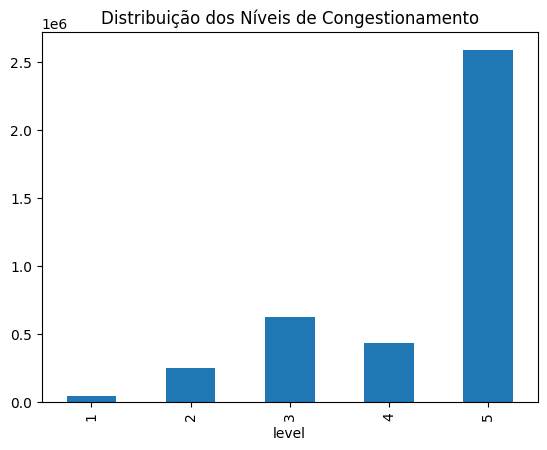

In [16]:
df_waze['level'].value_counts().sort_index().plot(kind='bar', title='Distribuição dos Níveis de Congestionamento')

print(df_waze['level'].value_counts().sort_index())


Extensão média por nível de severidade:
level
1    652.996273
2    620.416079
3    490.770764
4    384.369241
5     82.973469
Name: length, dtype: float64


<Axes: title={'center': 'Extensão Média por Nível de Severidade'}, xlabel='level'>

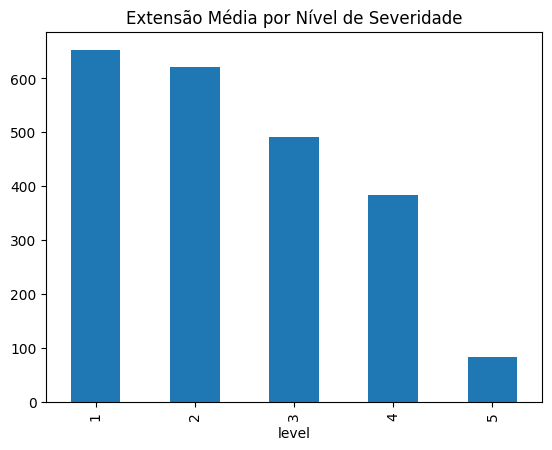

In [17]:
# Extensão média por nível de severidade
extensao_media_por_level = df_waze.groupby('level')['length'].mean()
print("Extensão média por nível de severidade:")
print(extensao_media_por_level)

# Plot
extensao_media_por_level.plot(kind='bar', title='Extensão Média por Nível de Severidade')

Velocidade média por nível de severidade (m/s):
level
1    3.448856
2    3.453369
3    2.402789
4    1.269273
5    0.000000
Name: speed, dtype: float64

Velocidade média por nível de severidade (km/h):
level
1    12.415883
2    12.432129
3     8.650040
4     4.569382
5     0.000000
Name: speed, dtype: float64


<Axes: title={'center': 'Velocidade Média por Nível'}, xlabel='level'>

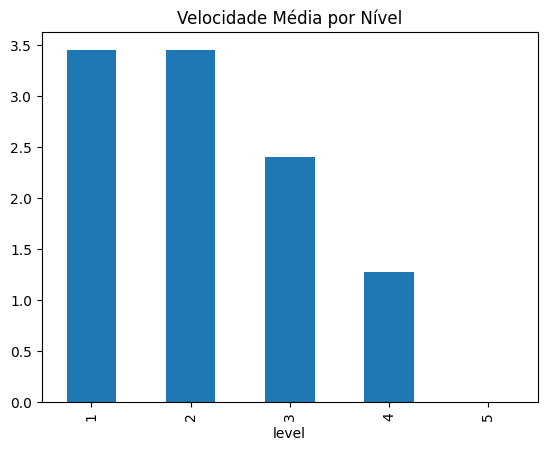

In [18]:
# Velocidade média por nível de severidade (em m/s)
velocidade_media_por_level = df_waze.groupby('level')['speed'].mean()
print("Velocidade média por nível de severidade (m/s):")
print(velocidade_media_por_level)

# Se quiseres em km/h:
velocidade_media_por_level_kmh = velocidade_media_por_level * 3.6
print("\nVelocidade média por nível de severidade (km/h):")
print(velocidade_media_por_level_kmh)

# Plot
velocidade_media_por_level.plot(kind='bar', title='Velocidade Média por Nível')

<Axes: title={'center': 'Atraso Médio por Hora do Dia'}, xlabel='entity_ts'>

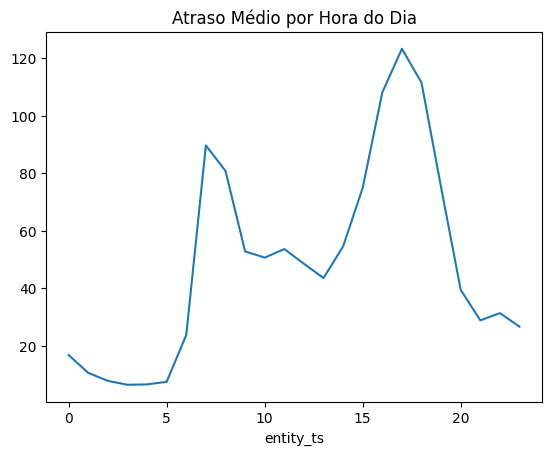

In [19]:
df_waze.groupby(df_waze['entity_ts'].dt.hour)['delay'].mean().plot(kind='line', title='Atraso Médio por Hora do Dia')

Número de ocorrências por hora no dia 2023-10-08:
entity_ts
0      1867
1      1759
2      1705
3      1655
4      1920
5      6609
6     13653
7     13731
8     13800
9     13939
10    14173
11    14393
12     4977
13     2810
14     2723
15     2750
16     2113
17     1911
18     2027
19     1800
20     1759
21     1809
22     2038
23     1574
Name: count, dtype: int64


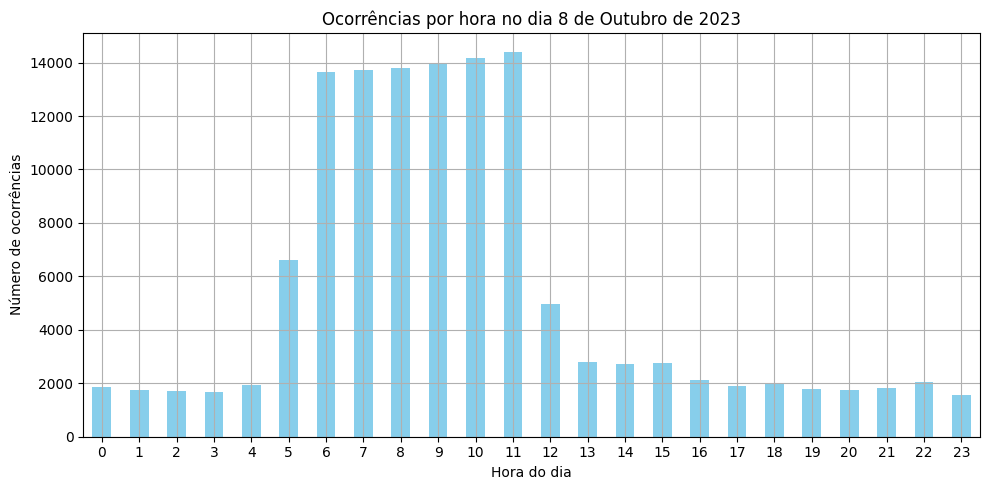

In [20]:
filtro_dia = df_waze['entity_ts'].dt.date == pd.to_datetime("2023-10-08").date()
df_dia_8 = df_waze[filtro_dia]
ocorrencias_por_hora = df_dia_8['entity_ts'].dt.hour.value_counts().sort_index()

print("Número de ocorrências por hora no dia 2023-10-08:")
print(ocorrencias_por_hora)
plt.figure(figsize=(10, 5))
ocorrencias_por_hora.plot(kind='bar', color='skyblue')
plt.title("Ocorrências por hora no dia 8 de Outubro de 2023")
plt.xlabel("Hora do dia")
plt.ylabel("Número de ocorrências")
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
zonas_top = df_dia_8['street'].value_counts().head(10)
print("\nTop 10 ruas com mais ocorrências no dia 2023-10-08:")
print(zonas_top)




Top 10 ruas com mais ocorrências no dia 2023-10-08:
street
Av. Inf. D. Henrique     6521
Av. D. João II           6369
Av. da Índia             5107
Av. 24 de Julho          4478
Av. D. Carlos I          3899
Av. Ribeira das Naus     3310
Av. da Liberdade         3205
Al. dos Oceanos          2362
R. Melo Antunes          2159
Estr. das Laranjeiras    2154
Name: count, dtype: int64


<Axes: title={'center': 'Top 10 Ruas com Mais Congestionamentos'}, ylabel='street'>

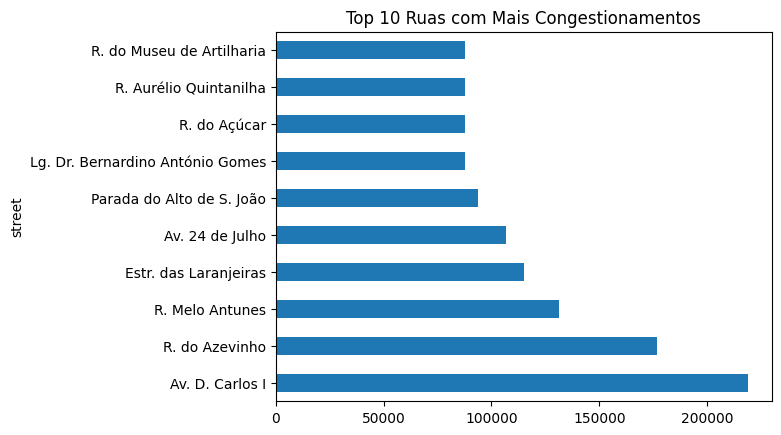

In [22]:
df_waze['street'].value_counts().head(10).plot(kind='barh', title='Top 10 Ruas com Mais Congestionamentos')


In [23]:
print(df_waze['street'].value_counts().head(10))

street
Av. D. Carlos I                     218904
R. do Azevinho                      176834
R. Melo Antunes                     131490
Estr. das Laranjeiras               114934
Av. 24 de Julho                     106613
Parada do Alto de S. João            93978
Lg. Dr. Bernardino António Gomes     87777
R. do Açúcar                         87678
R. Aurélio Quintanilha               87541
R. do Museu de Artilharia            87536
Name: count, dtype: int64


In [24]:
dias_uteis = df_waze[df_waze['entity_ts'].dt.dayofweek < 5]

# Top 10 ruas mais afetadas em dias úteis
top_ruas_uteis = dias_uteis['street'].value_counts().head(10)
print("Ruas mais afetadas durante a semana (dias úteis):")
print(top_ruas_uteis)

Ruas mais afetadas durante a semana (dias úteis):
street
Av. D. Carlos I                     153920
R. do Azevinho                      127433
R. Melo Antunes                      92532
Estr. das Laranjeiras                81407
Av. 24 de Julho                      74386
Parada do Alto de S. João            66133
R. do Açúcar                         61677
Lg. Dr. Bernardino António Gomes     61645
R. Aurélio Quintanilha               61606
R. do Museu de Artilharia            61595
Name: count, dtype: int64


In [25]:
fins_de_semana = df_waze[df_waze['entity_ts'].dt.dayofweek >= 5]

# Top 10 ruas mais afetadas aos fins de semana
top_ruas_fim_semana = fins_de_semana['street'].value_counts().head(10)
print("\nRuas mais afetadas aos fins de semana:")
print(top_ruas_fim_semana)


Ruas mais afetadas aos fins de semana:
street
Av. D. Carlos I                     64984
R. do Azevinho                      49401
R. Melo Antunes                     38958
Estr. das Laranjeiras               33527
Av. 24 de Julho                     32227
Parada do Alto de S. João           27845
Lg. Dr. Bernardino António Gomes    26132
R. do Açúcar                        26001
R. do Museu de Artilharia           25941
R. Aurélio Quintanilha              25935
Name: count, dtype: int64


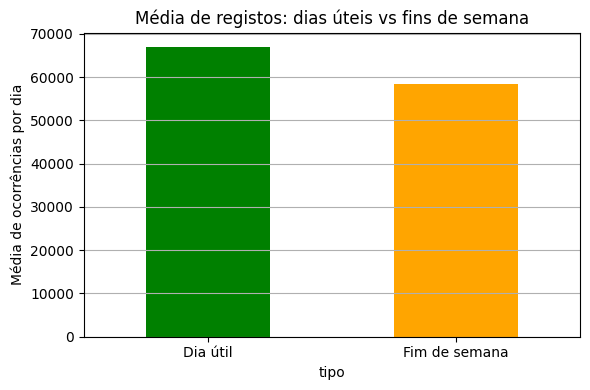


Média de ocorrências por tipo de dia:
tipo
Dia útil         66907.604651
Fim de semana    58532.111111
Name: contagem, dtype: float64


In [26]:
# Conta registos por dia
registos_por_dia = df_waze.groupby(df_waze['entity_ts'].dt.date).size().reset_index(name='contagem')

# Cria coluna tipo de dia sem guardar no DataFrame original
registos_por_dia['tipo'] = registos_por_dia['entity_ts'].apply(
    lambda d: 'Dia útil' if pd.to_datetime(d).dayofweek < 5 else 'Fim de semana'
)

media_tipo_dia = registos_por_dia.groupby('tipo')['contagem'].mean()

plt.figure(figsize=(6, 4))
media_tipo_dia.plot(kind='bar', color=['green', 'orange'])
plt.title('Média de registos: dias úteis vs fins de semana')
plt.ylabel('Média de ocorrências por dia')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print("\nMédia de ocorrências por tipo de dia:")
print(media_tipo_dia)

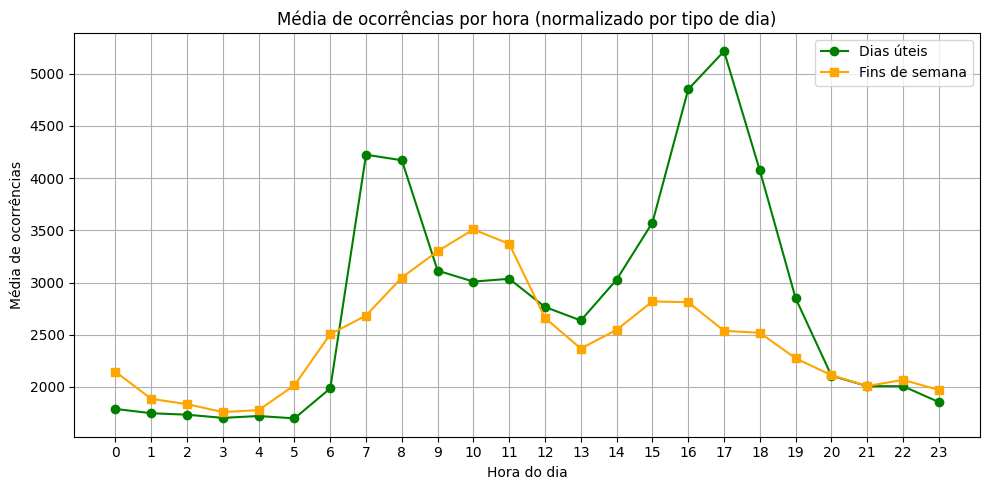

In [27]:
# Conta o número de dias distintos por tipo
df_temp = df_waze.copy()
df_temp['tipo'] = df_temp['entity_ts'].dt.dayofweek.apply(lambda x: 'Dia útil' if x < 5 else 'Fim de semana')
df_temp['data'] = df_temp['entity_ts'].dt.date
dias_distintos = df_temp[['data', 'tipo']].drop_duplicates().groupby('tipo').size()

# Conta número total de registos por hora e tipo de dia (sem criar colunas no df_waze original)
ocorrencias_por_hora = (
    df_waze
    .assign(tipo=df_waze['entity_ts'].dt.dayofweek.apply(lambda x: 'Dia útil' if x < 5 else 'Fim de semana'),
            hora=df_waze['entity_ts'].dt.hour)
    .groupby(['tipo', 'hora'])
    .size()
    .reset_index(name='total_ocorrencias')
)

# Junta com número de dias para normalizar (média por hora)
ocorrencias_por_hora['dias_totais'] = ocorrencias_por_hora['tipo'].map(dias_distintos)
ocorrencias_por_hora['media_por_hora'] = ocorrencias_por_hora['total_ocorrencias'] / ocorrencias_por_hora['dias_totais']

pivot_normalizado = ocorrencias_por_hora.pivot(index='hora', columns='tipo', values='media_por_hora').fillna(0)

plt.figure(figsize=(10, 5))
plt.plot(pivot_normalizado.index, pivot_normalizado['Dia útil'], marker='o', label='Dias úteis', color='green')
plt.plot(pivot_normalizado.index, pivot_normalizado['Fim de semana'], marker='s', label='Fins de semana', color='orange')

plt.title('Média de ocorrências por hora (normalizado por tipo de dia)')
plt.xlabel('Hora do dia')
plt.ylabel('Média de ocorrências')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Número de ocorrências por hora no dia 2023-10-05:
entity_ts
0     1594
1     1531
2     1445
3     1496
4     1540
5     1562
6     1712
7     1691
8     1922
9     2480
10    2789
11    2346
12    2052
13    1947
14    1988
15    2296
16    2241
17    1806
18    1858
19    2468
20    1752
21    1702
22    1696
23    1584
Name: count, dtype: int64


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23]),
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23')])

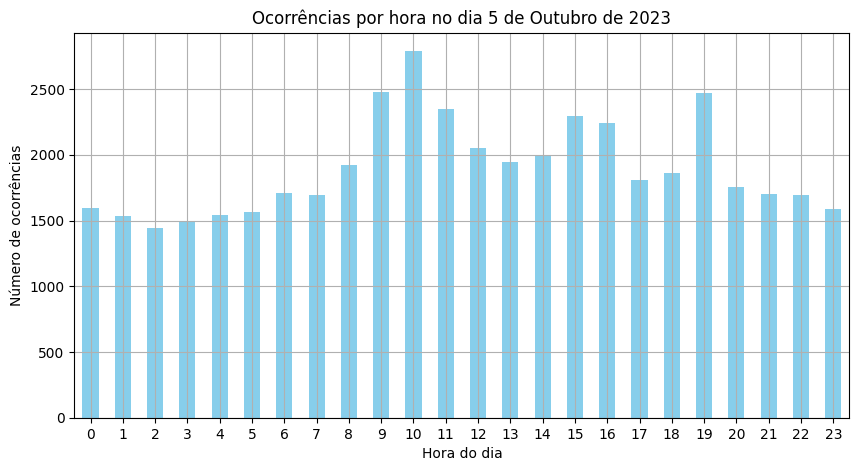

In [28]:
filtro_dia = df_waze['entity_ts'].dt.date == pd.to_datetime("2023-10-05").date()
df_dia_5 = df_waze[filtro_dia]
ocorrencias_por_hora = df_dia_5['entity_ts'].dt.hour.value_counts().sort_index()

print("Número de ocorrências por hora no dia 2023-10-05:")
print(ocorrencias_por_hora)
plt.figure(figsize=(10, 5))
ocorrencias_por_hora.plot(kind='bar', color='skyblue')
plt.title("Ocorrências por hora no dia 5 de Outubro de 2023")
plt.xlabel("Hora do dia")
plt.ylabel("Número de ocorrências")
plt.grid(True)
plt.xticks(rotation=0)

In [29]:
df_waze_sem_bloqueio = df_waze[df_waze['delay'] != -1]

atraso_por_dia_semana = (
    df_waze_sem_bloqueio
    .groupby(df_waze_sem_bloqueio['entity_ts'].dt.dayofweek)['delay']
    .mean()
    .reset_index()
    .sort_values('entity_ts')
)
atraso_por_dia_semana.columns = ['dia_da_semana', 'delay']
print("Atraso médio por dia da semana (sem vias bloqueadas):")
display(atraso_por_dia_semana)

atraso_por_hora = (
    df_waze_sem_bloqueio
    .groupby(df_waze_sem_bloqueio['entity_ts'].dt.hour)['delay']
    .mean()
    .reset_index()
    .sort_values('entity_ts')
)
atraso_por_hora.columns = ['hora', 'delay']
print("Atraso médio por hora do dia (sem vias bloqueadas):")
display(atraso_por_hora)

atraso_medio_global = df_waze_sem_bloqueio['delay'].mean()
print(f"Atraso médio global (sem vias bloqueadas): {atraso_medio_global:.2f}")

Atraso médio por dia da semana (sem vias bloqueadas):


,dia_da_semana,delay
0,0,163.445784
1,1,206.028386
2,2,179.638354
3,3,167.231922
4,4,163.152057
5,5,155.105265
6,6,157.850987


Atraso médio por hora do dia (sem vias bloqueadas):


,hora,delay
0,0,148.783877
1,1,140.372763
2,2,136.326287
3,3,140.211198
4,4,132.233149
5,5,140.927811
6,6,165.446459
7,7,185.762500
8,8,173.442027
9,9,155.595873


Atraso médio global (sem vias bloqueadas): 174.82


In [30]:
atraso_tipo_dia = (
    df_waze_sem_bloqueio
    .groupby(df_waze_sem_bloqueio['entity_ts'].dt.dayofweek.apply(lambda x: 'Dia útil' if x < 5 else 'Fim de semana'))['delay']
    .mean()
    .reset_index(name='delay')
    .rename(columns={'entity_ts': 'tipo_dia'})
)
display(atraso_tipo_dia)

,tipo_dia,delay
0,Dia útil,177.973420
1,Fim de semana,156.125035


In [31]:
# Top 5 dias com maior atraso médio (ignorando vias bloqueadas)
top5_dias = (
    df_waze[df_waze['delay'] != -1]
    .groupby(df_waze['entity_ts'].dt.date)['delay']
    .mean()
    .reset_index(name='Atraso Médio')
    .sort_values('Atraso Médio', ascending=False)
    .head(5)
)
print("Top 5 dias com maior atraso médio:")
display(top5_dias)

Top 5 dias com maior atraso médio:


,entity_ts,Atraso Médio
53,2023-10-24,341.097882
12,2023-09-13,206.775831
23,2023-09-24,190.082263
28,2023-09-29,182.331975
19,2023-09-20,181.457085


In [32]:
for _, row in top5_dias.iterrows():
    data = row['entity_ts']
    print(f"\nTop ruas com maior atraso em {data}:")
    
    df_dia = df_waze[(df_waze['entity_ts'].dt.date == data) & (df_waze['delay'] != -1)]
    atraso_top_ruas = (
        df_dia.groupby('street')['delay']
        .mean()
        .reset_index(name='Atraso Médio')
        .sort_values('Atraso Médio', ascending=False)
        .head(10)
    )
    display(atraso_top_ruas)


Top ruas com maior atraso em 2023-10-24:


,street,Atraso Médio
112,"Ac. Pte. {S}, Setúbal, Almada",2374.844037
402,Estr. de Monsanto,2178.504673
265,Av. Ten. Martins,2167.774648
842,R. Jorge Alves,1663.000000
46,"Ac. A2 {S}, Almada",1557.594595
431,IP7 / Eixo N-S,1515.205011
686,R. D. Francisco D`Eça,1410.500000
1069,R. Silva de Albuquerque,1185.000000
60,"Ac. Amoreiras, Campolide",1124.142857
933,R. Marcelino Mesquita,1068.875000



Top ruas com maior atraso em 2023-09-13:


,street,Atraso Médio
831,R. da Academia Rec. e Musical de Sacavém,1831.333333
68,"Ac. Pte. {S}, Setúbal, Almada",1179.806452
793,R. Sinais de Fogo,1137.000000
179,Av. Rui Nogueira Simões,1087.400000
748,R. Prof. José Pinto Correia,1038.750000
319,IP7 / Eixo N-S,1007.190476
212,Av. de Paris,964.666667
652,R. Luís Monteiro,953.000000
979,R. do Paraíso,921.666667
464,R. Cid. de Quelimane,909.400000



Top ruas com maior atraso em 2023-09-24:


,street,Atraso Médio
559,R. Viana da Mota,3236.000000
411,R. Jorge Alves,1761.000000
187,Passeio do Cantábrico,1684.000000
504,R. Prof. Dr. António Luciano Pacheco de Sousa ...,1630.000000
175,IP7 / Eixo N-S,1230.921348
20,"Ac. Pte. {S}, Setúbal, Almada",1155.266667
618,R. das Garridas,1132.000000
730,Tv. do Combro,1001.500000
360,R. Fernando Farinha,984.700000
359,R. Fernando Curado Ribeiro,897.000000



Top ruas com maior atraso em 2023-09-29:


,street,Atraso Médio
640,R. Francisco Marcelo Curto,1945.000000
634,R. Fr. Manuel Cardoso,1942.000000
1137,Ramal de Benfica,1609.425000
373,Pç. João do Rio,1372.750000
1160,Tv. do Possolo,1108.333333
1036,R. de S. João de Brito,1097.250000
660,R. Gen. Massano de Amorim,1047.000000
843,R. Prof. Hernâni Cidade,1034.500000
550,R. D. Luís Coutinho,1030.800000
1096,R. do Pólo Sul,973.000000



Top ruas com maior atraso em 2023-09-20:


,street,Atraso Médio
563,R. Cupertino de Miranda,2048.500000
695,R. Jorge Alves,1429.600000
431,R. Acácio de Paiva,1117.000000
914,R. Vicente Dias,1115.333333
622,R. Epifânio Dias,1108.909091
900,R. Teófilo Carvalho dos Santos,1040.000000
644,R. Francisco Cortês Pinto,964.000000
433,R. Afonso Annes Penedo,961.750000
825,R. Pedro de Barcelos,936.000000
1054,R. do Açúcar,926.000000


Atraso médio no dia 8 de outubro de 2023: 161.29
Correlação entre atraso médio e número de ocorrências por dia: 0.69


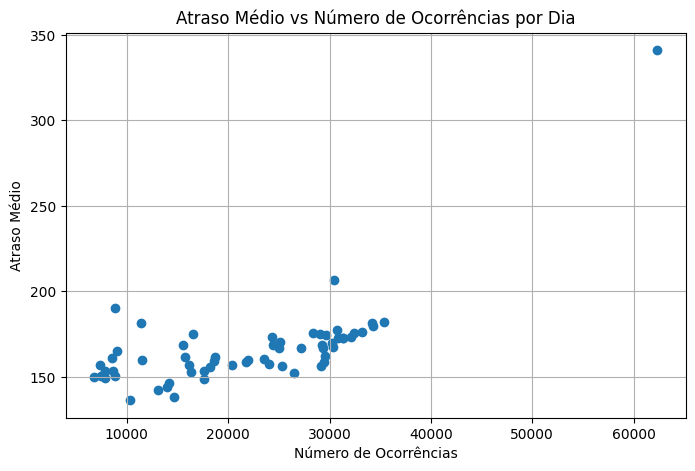

In [33]:
data_8 = pd.to_datetime("2023-10-08").date()
df_dia_8 = df_waze_sem_bloqueio[df_waze_sem_bloqueio['entity_ts'].dt.date == data_8]

atraso_medio_8 = df_dia_8['delay'].mean()
print(f"Atraso médio no dia 8 de outubro de 2023: {atraso_medio_8:.2f}")

# Ocorrências por dia
ocorrencias_por_dia = (
    df_waze_sem_bloqueio
    .groupby(df_waze_sem_bloqueio['entity_ts'].dt.date)
    .size()
    .reset_index(name='ocorrencias')
)

# Atraso médio por dia
atraso_medio_por_dia = (
    df_waze_sem_bloqueio
    .groupby(df_waze_sem_bloqueio['entity_ts'].dt.date)['delay']
    .mean()
    .reset_index(name='atraso_medio')
)

# Merge e correlação
analise = pd.merge(ocorrencias_por_dia, atraso_medio_por_dia, on='entity_ts')
correlacao = analise['ocorrencias'].corr(analise['atraso_medio'])
print(f"Correlação entre atraso médio e número de ocorrências por dia: {correlacao:.2f}")

plt.figure(figsize=(8,5))
plt.scatter(analise['ocorrencias'], analise['atraso_medio'])
plt.xlabel('Número de Ocorrências')
plt.ylabel('Atraso Médio')
plt.title('Atraso Médio vs Número de Ocorrências por Dia')
plt.grid(True)

In [34]:
# Level mais comum no dia 8 de outubro de 2023
contagem_levels_8 = df_waze[df_waze['entity_ts'].dt.date == data_8]['level'].value_counts()
level_mais_comum_8 = contagem_levels_8.idxmax()
print("Contagem dos níveis no dia 8 de outubro de 2023:")
print(contagem_levels_8)
print(f"\nLevel mais comum no dia 8 de outubro de 2023: {level_mais_comum_8}")

Contagem dos níveis no dia 8 de outubro de 2023:
level
5    118933
3      3898
4      2466
2      1815
1       383
Name: count, dtype: int64

Level mais comum no dia 8 de outubro de 2023: 5


In [35]:
atraso_por_level = df_waze_sem_bloqueio.groupby('level')['delay'].mean().reset_index()
display(atraso_por_level)

,level,delay
0,1,77.157437
1,2,88.467079
2,3,129.261309
3,4,297.647889


In [36]:
def extrair_primeira_coordenada_regex(pos_str):
    """
    Usa Expressões Regulares para encontrar todos os pares [lon, lat]
    e retorna o primeiro que encontrar.
    """
    if not isinstance(pos_str, str):
        return np.nan, np.nan
        
    matches = re.findall(r'\[(-?\d+\.\d+),\s*(-?\d+\.\d+)\]', pos_str)
    
    if matches:
      
        primeiro_match = matches[0]
   
        longitude = float(primeiro_match[0])
        latitude = float(primeiro_match[1])
        return latitude, longitude
    else:
       
        return np.nan, np.nan

df_waze[['latitude', 'longitude']] = df_waze['position'].apply(
    lambda x: pd.Series(extrair_primeira_coordenada_regex(x))
)

In [37]:
df_waze['dia_semana'] = df_waze['entity_ts'].dt.weekday + 1  # Segunda=1, ..., Domingo=7
df_waze['hora'] = df_waze['entity_ts'].dt.hour
feriados = [pd.to_datetime('2023-10-05').date()]
df_waze['feriado'] = df_waze['entity_ts'].dt.date.isin(feriados).astype(int)

# Criação da variável de localização 'zona_id'
precisao_zona = 3  # Arredondamento a 3 casas decimais (~110 metros)
df_waze['zona_id'] = df_waze['latitude'].round(precisao_zona).astype(str) + '_' + df_waze['longitude'].round(precisao_zona).astype(str)

# Remover ocorrências de ruas cortadas
df_waze_filtrado = df_waze[df_waze['delay'] != -1].copy()


chaves_agregacao = ['zona_id', 'dia_semana', 'hora', 'feriado']
df_waze_agg = df_waze_filtrado.groupby(chaves_agregacao).agg(
    atraso_medio_waze=('delay', 'mean')
).reset_index()

# Grelha completa para imputação
zonas = df_waze_filtrado['zona_id'].unique()
dias_semana = range(1, 8)
horas = range(0, 24)
feriados_possiveis = [0, 1]

multi_index = pd.MultiIndex.from_product(
    [zonas, dias_semana, horas, feriados_possiveis],
    names=chaves_agregacao
)
df_grelha_completa = pd.DataFrame(index=multi_index).reset_index()

df_waze_completo = pd.merge(
    df_grelha_completa,
    df_waze_agg,
    on=chaves_agregacao,
    how='left'
)


mediana_atraso_por_grupo = df_waze_completo.groupby(['dia_semana', 'hora'])['atraso_medio_waze'].transform('median')
df_waze_completo['atraso_medio_waze'].fillna(mediana_atraso_por_grupo, inplace=True)

mediana_global_atraso = df_waze_completo['atraso_medio_waze'].median()
df_waze_completo['atraso_medio_waze'].fillna(mediana_global_atraso, inplace=True)


In [38]:
df_waze_completo.to_csv('waze_dados_preparados.csv', index=False)

In [39]:
df_waze_completo.head(10)

,zona_id,dia_semana,hora,feriado,atraso_medio_waze
0,38.729_-9.133,1,0,0,644.571429
1,38.729_-9.133,1,0,1,103.000000
2,38.729_-9.133,1,1,0,76.000000
3,38.729_-9.133,1,1,1,103.375000
4,38.729_-9.133,1,2,0,152.000000
5,38.729_-9.133,1,2,1,101.000000
6,38.729_-9.133,1,3,0,104.000000
7,38.729_-9.133,1,3,1,104.000000
8,38.729_-9.133,1,4,0,101.000000
9,38.729_-9.133,1,4,1,101.000000
